<a href="https://colab.research.google.com/github/mateoportillo1900/Spotify-ML-Model/blob/main/Spotify_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Music Data
This dataset consists of -600 songs that were in the top songs of the year from 2010 to 2019 (as measured by Billboard). You can explore interesting song data pulled from Spotify L such as the beats per minute, amount of spoken words, loudness, and energy of every song.


## 📘 Data Dictionary: `spotify_top_music.csv`

| **Column Name** | **Description** |
|-----------------|-----------------|
| `title`         | Title of the song |
| `artist`        | Artist who performed the song |
| `top_genre`     | Primary genre classification of the song |
| `year`          | Year the song was included in Billboard charts |
| `bpm`           | Beats per minute — tempo of the song |
| `nrgy`          | Energy level (0–100) — higher values mean more energetic (fast, loud, intense) |
| `dnce`          | Danceability (0–100) — higher values mean easier to dance to |
| `dB`            | Loudness in decibels |
| `live`          | Liveness — likelihood the track was recorded with a live audience |
| `val`           | Valence (0–100) — higher values mean more positive/happy sounding |
| `dur`           | Duration of the song (in seconds) |
| `acous`         | Acousticness (0–100) — higher values mean more acoustic |
| `spch`          | Speechiness (0–100) — higher values mean more spoken content (e.g., rap, talk) |
| `pop`           | Popularity score (0–100) — higher values mean more popular |

### 🔗 Source
- Dataset created from public Spotify + Billboard chart data.
- Hosted in GitHub: `spotify_top_music.csv`

In [49]:
import pandas as pd
from google.colab import drive

url = "https://raw.githubusercontent.com/mateoportillo1900/Spotify-ML-Model/refs/heads/main/spotify_top_music.csv"
spotify = pd.read_csv(url)


##spotify = pd.read_csv("spotify_top_music.csv", index_col=0)
print(spotify.shape)
spotify.head(100)

(603, 14)


,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Castle Walls (feat. Christina Aguilera),T.I.,atl hip hop,2011,80,86,45,-5,26,58,329,7,39,49
96,Turning Page,Sleeping At Last,acoustic pop,2011,125,38,30,-8,11,19,255,91,3,46
97,Super Bass,Nicki Minaj,dance pop,2011,127,74,77,-7,40,59,201,6,23,38
98,Raise Your Glass,P!nk,dance pop,2011,122,64,68,-7,12,56,208,0,12,38


# Objective

🔎 Analyze: Train and build a classifer to predict a song's genre based on song attributes.

In [50]:
# Data Imports
import pandas as pd
import numpy as np

# Visualization imports
import matplotlib.pyplot as plt
import plotly.express as px
plt.rcParams['figure.figsize'] = [8, 4]



# ML Imports
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [51]:
round(spotify.describe())

,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
count,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0
mean,2015.0,119.0,71.0,64.0,-6.0,18.0,52.0,225.0,14.0,8.0,67.0
std,3.0,25.0,16.0,13.0,3.0,13.0,23.0,34.0,21.0,7.0,15.0
min,2010.0,0.0,0.0,0.0,-60.0,0.0,0.0,134.0,0.0,0.0,0.0
25%,2013.0,100.0,61.0,57.0,-6.0,9.0,35.0,202.0,2.0,4.0,60.0
50%,2015.0,120.0,74.0,66.0,-5.0,12.0,52.0,221.0,6.0,5.0,69.0
75%,2017.0,129.0,82.0,73.0,-4.0,24.0,69.0,240.0,17.0,9.0,76.0
max,2019.0,206.0,98.0,97.0,-2.0,74.0,98.0,424.0,99.0,48.0,99.0


In [52]:
# Define Modules

# Define the models
models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Decision Tree": DecisionTreeClassifier(random_state=123),
"Random Forest": RandomForestClassifier(n_estimators=100, random_state=123),
"Support Vector Classifier": SVC()
}

# Preprocess the Data

In [53]:
# Set up cross-validation
split = KFold(n_splits=4, shuffle=True, random_state=1234)

# Preprocess numerical features
features_num = ["year", "bpm", "nrgy", "dnce", "db", "live", "val", "dur", "acous", "spch", "pop"]
transformer_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant")),
    ("scaler", StandardScaler())
])

# Preprocess categorical features
features_cat = ["artist"]
transformer_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ("num", transformer_num, features_num),
    ("cat", transformer_cat, features_cat)
])

# Define input features and target variable
features = features_num + features_cat

# Clean column names for safety
spotify.columns = spotify.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop classes with <5 samples (optional but avoids cross-val issues)
y_counts = spotify["top_genre"].value_counts()
spotify = spotify[~spotify["top_genre"].isin(y_counts[y_counts < 5].index)]

X = spotify[features]
y = spotify["top_genre"]

In [54]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd


# Define your models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Drop classes with <2 samples (needed for stratified split)
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=y
)

# Train and evaluate each model
results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results[model_name] = {
        "Accuracy": accuracy,
        "Classification Report": report
    }

# Cross-validation
cv_results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=4, scoring="accuracy", n_jobs=-1)
    cv_results[model_name] = scores

# Summarize CV results
summary = {}

for model_name, scores in cv_results.items():
    summary[model_name] = {
        "Min Accuracy": round(np.min(scores), 4),
        "Max Accuracy": round(np.max(scores), 4),
        "Mean Accuracy": round(np.mean(scores), 4)
    }

# Display final result
results_df = pd.DataFrame(summary).T
print(results_df)

                        Min Accuracy  Max Accuracy  Mean Accuracy
Logistic Regression           0.7474        0.8105         0.7842
Random Forest                 0.7368        0.8526         0.8026
Support Vector Machine        0.6000        0.6211         0.6079
Decision Tree                 0.8842        0.9474         0.9184


# Model Evaluation on Test Set
Random Forest is the best model based on the cross validation, so lets evaluate it on the test set to get an unbiased estimate of it's performance.

In [55]:
# Evaluate the best model on the test set
best_model = RandomForestClassifier(n_estimators=100, random_state=123)

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
classification = classification_report(y_test, y_pred, zero_division=0)

# Print results
print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Classification Report:\n{classification}")

Test Set Accuracy: 0.8354
Classification Report:
                           precision    recall  f1-score   support

                  art pop       0.00      0.00      0.00         2
              atl hip hop       1.00      1.00      1.00         1
         australian dance       1.00      0.50      0.67         2
           australian pop       0.00      0.00      0.00         1
            barbadian pop       1.00      1.00      1.00         5
                 big room       0.00      0.00      0.00         3
                 boy band       1.00      0.40      0.57         5
             british soul       1.00      0.33      0.50         3
canadian contemporary r&b       1.00      1.00      1.00         3
             canadian pop       1.00      0.90      0.95        10
               complextro       1.00      1.00      1.00         2
                dance pop       0.80      0.99      0.88        99
                      edm       0.00      0.00      0.00         1
            

# Hyper Parameter Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Run Grid Search with 3-fold CV
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract best model and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Cross-Validation Score: 0.7973


# Feature Importance
Analysis of the feature importance to understand which features are most influential in the model

In [59]:
# Extract feature names from pipeline
num_features = features_num

# Get encoded categorical feature names
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(features_cat).tolist()

# Combine full list of features
all_features = num_features + cat_feature_names

# Get feature importances from trained RandomForest model
importances = pipeline.named_steps['model'].feature_importances_

# Build DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Optional: save for Tableau use
feature_importance_df.to_csv("feature_importance.csv", index=False)

# Optional: download CSV in Colab
# from google.colab import files
# files.download("feature_importance.csv")

# Interactive Plotly Bar Chart
import plotly.express as px

fig = px.bar(
    feature_importance_df.head(20),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 20 Most Influential Features (Random Forest)',
    text='Importance'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    template='plotly_white'
)
fig.show()

Why: Shows how well the model is classifying each genre. Highlights misclassifications.

Bar chart
Genre distribution in the dataset

Heatmap
Raw confusion matrix showing count of predictions

Heatmap
Normalized confusion matrix showing model performance per class


In [66]:
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 1. 📊 Class Distribution — Interactive Bar Chart
class_counts = y.value_counts().reset_index()
class_counts.columns = ['Genre', 'Count']

fig = px.bar(
    class_counts,
    x='Genre',
    y='Count',
    title='Genre Distribution in Dataset',
    color='Genre',
    text='Count'
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

# 2. 🔁 Retrain model with class weighting
balanced_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', balanced_model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# 3. 📐 Confusion Matrix — Raw Counts
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
fig_cm = px.imshow(
    cm_df,
    text_auto=True,
    aspect='auto',
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    title="Confusion Matrix (Raw Counts)"
)
fig_cm.update_xaxes(side="bottom")
fig_cm.show()

# 4. 📐 Confusion Matrix — Normalized
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
cm_norm_df = pd.DataFrame(np.round(cm_norm, 2), index=labels, columns=labels)

fig_cm_norm = px.imshow(
    cm_norm_df,
    text_auto=True,
    aspect='auto',
    labels=dict(x="Predicted Label", y="True Label", color="Proportion"),
    title="Confusion Matrix (Normalized by True Class)"
)
fig_cm_norm.update_xaxes(side="bottom")
fig_cm_norm.show()

Why: For multi-class classification, this shows how well each class is separated.

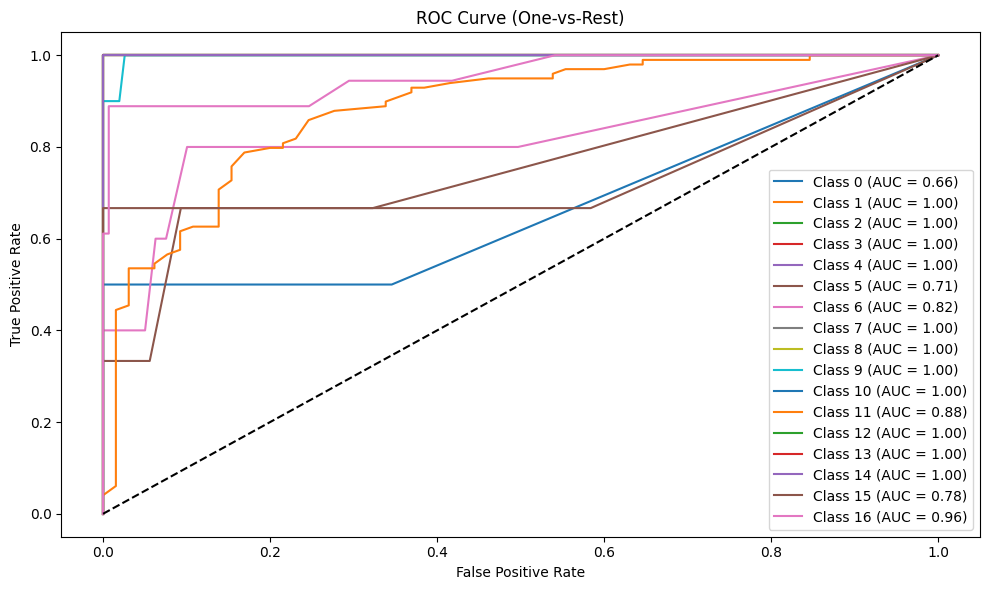

In [61]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Binarize y_test for ROC
y_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_bin.shape[1]

# Fit One-vs-Rest model
ovr_model = OneVsRestClassifier(pipeline)
ovr_model.fit(X_train, label_binarize(y_train, classes=np.unique(y_test)))

# Predict probabilities
y_score = ovr_model.predict_proba(X_test)

# Plot ROC
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

Why: Adds depth to show which genres differ by energy, valence, danceability, etc.

Text(0.5, 1.0, 'Energy Distribution by Genre')

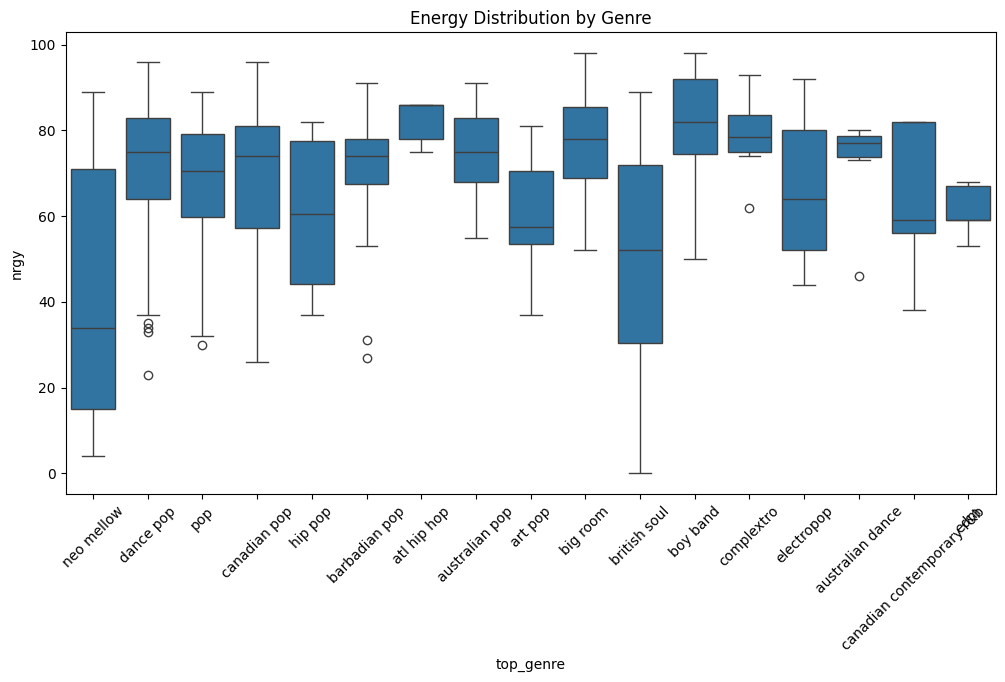

In [62]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='top_genre', y='nrgy', data=spotify)
plt.xticks(rotation=45)
plt.title('Energy Distribution by Genre')

Why: Shows whether different genres form visually distinct clusters in feature space.

Text(0.5, 1.0, 't-SNE Embedding of Songs by Genre')

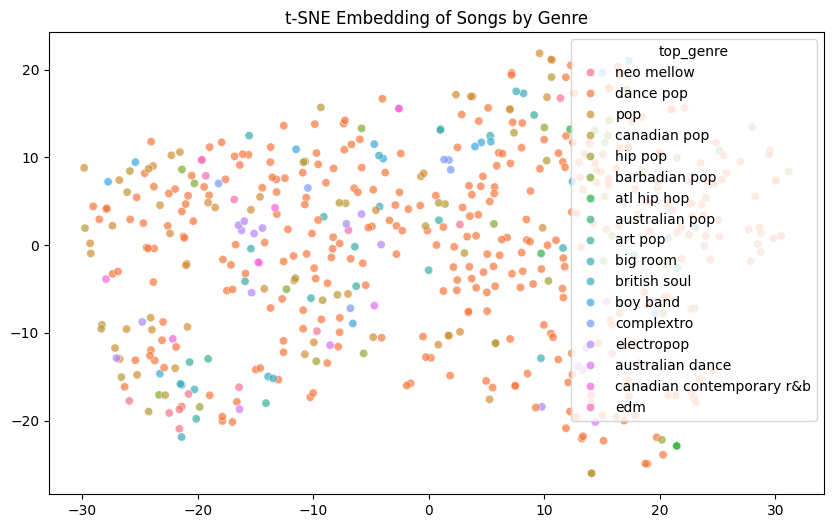

In [64]:
from sklearn.manifold import TSNE
X_transformed = preprocessor.fit_transform(X).toarray()  # Convert to dense matrix
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X_transformed)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y, alpha=0.7)
plt.title('t-SNE Embedding of Songs by Genre')